# Biomedical Image Analysis Pipeline: Fluorescence-Microscopy Nuclei

**Module:** Data Analysis with AI &nbsp;|&nbsp; **Modality:** Fluorescence microscopy (DAPI-style stained nuclei) &nbsp;|&nbsp; **Dataset used:** is a synthetic Stained-Nuclei Dataset (`nuclei_dataset`) (80 train / 20 val / 12 test / 4 corrupted)

This notebook implements the full pipeline: **raw image -> segmentation -> quantitative
region features -> structured JSON record -> short narrative**, combining:

- **Task 1:** Includes data preparation, EDA, and a local multimodal LLM (llama3.2-vision via Ollama)
- **Task 2:** classical image features (Otsu + regionprops) and a numbers-only LLM interpretation
- **Task 3:** is a compact U-Net trained to segment nuclei, evaluated with Dice/IoU
- **Task 4:** the hybrid pipeline run end-to-end on unseen test images, aggregated to a CSV
- **Extensions for extra credit:** (a) a loss-function ablation (BCE vs Dice vs BCE+Dice), and (b) a robustness
  trace showing how image corruption propagates through the pipeline (c) replacing U-Net with a 
  pretrained medical segmentation model (**MedSAM**)

All pipeline logic lives in `pipeline_utils.py` (imported below) so this notebook stays
focused on *running* and *interpreting* the pipeline rather than re-defining it in every cell.

> **Note on the LLM steps (Ollama):** cells that call a local Ollama model are guarded with an
> availability check. If Ollama / the required model isn't running on the machine that executes
> this notebook, those cells print a clear message and skip instead of crashing the
> whole notebook, but the exact code that performs the real call is shown and will run as-is
> once `ollama serve` and `ollama pull llama3.2-vision` (and `ollama pull llama3.2` for the
> text-only step) have been done locally.


## Setup

### Installing Ollama and pulling the two models

This notebook uses the same `ollama` taught in tutorial 2
although i have since updated to every recent version of ollama <br> 
but I had to delete the recent version and download the version before <br> `v0.30.0` which was `v0.24.0:` to enable `llama3.2-vision` run successfully. This is because, recent Ollama versions (v0.30.0 upwards) have a current bug where
`llama3.2-vision` downloads successfully but crashes with `unknown model architecture:
`mllama` the moment it's used. So to avoid it,
this notebook was run with **Ollama v0.24.0** the last version before the issue came up.


**Steps followed:**

1. **Downloaded the v0.24.0 installer** directly from GitHub releases:
   https://github.com/ollama/ollama/releases/tag/v0.24.0
   (Windows installer under "Assets" on that page, not the latest-version installer
   from ollama.com/download, which would reintroduce the bug above.)
2. **Installed it**, then verified the version from Command Prompt:

      `ollama --version`

   confirming it reports `0.24.0`, not a newer version.
3. **Pulled both models** needed by this notebook:

      `ollama pull llama3.2-vision` <br>
      `ollama pull llama3.2`

4. **Disabled automatic updates** in the Ollama desktop app settings, so it doesn't
   silently update itself back to a broken newer version between sessions.
5. Confirmed both models load correctly by running **tutorial 1**'s and **tutorial 2**'s own setup
   cells first, before running this notebook.

With this in place, the Setup cell below should print:

   `Ollama vision model ready: True` <br>
   `Ollama text model ready: True`

VS Code was used for this analysis, If your pc is slow or short on disk space, Lab 2's Colab setup cells (GPU-accelerated
download and inference) are a drop-in alternative just re-point `DATA_ROOT` at the
uploaded dataset inside Colab.

### What the next code cell does

Imports the pipeline module and standard libraries, sets a random seed so the U-Net
training in Task 3 is reproducible, sets a consistent semibold title style for every
plot in this notebook, creates the `outputs/` and `outputs/figures/` folders (every
plot-producing cell below saves a PNG copy there, in addition to displaying inline, so
the figures are available as standalone files for the report), and checks whether Ollama
+ the two required models are reachable on this machine (the Task 1/2/4 LLM cells use
this to decide whether to make a real call or print a helpful skip message).


---

In [11]:
# Standard library / third-party imports
import os, sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

warnings.filterwarnings("ignore")  # silence noisy skimage deprecation warnings (not errors)
sys.path.insert(0, ".")

# All plot titles in this notebook use a semibold weight (set once, applies globally)
plt.rcParams["axes.titleweight"] = "semibold"

# Our own pipeline functions (see pipeline_utils.py for full docstrings) --
from pipeline_utils import (
    # I/O & preprocessing
    load_image_rgb, to_grayscale_resized, load_mask_binary, dataset_intensity_histogram,
    # Ollama client
    query_ollama, extract_json_block,
    # Classical features
    segment_otsu, compute_region_table, summarize_region_table,
    # U-Net
    UNet, NucleiSegDataset, train_unet, evaluate_unet,
    # Losses & metrics
    DiceLoss, BCEDiceLoss, dice_coefficient, iou_score,
    # Helpers
    list_split,
)

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DATA_ROOT = "nuclei_dataset"
IMG_SIZE = (256, 256)

# Ensure the output directory exists. Git does not track empty folders, so a
# fresh clone of the repository will NOT have "outputs/" present even though
# it exists in the original project, every cell that writes a result there
# (Task 1's VLM run log, the trained U-Net weights, Task 4's CSV, the
# ablation results, etc.) would otherwise fail with a "Parent directory does
# not exist" error. Creating it once here, defensively, fixes that for every
# subsequent cell in this notebook.
os.makedirs("outputs", exist_ok=True)
os.makedirs("outputs/figures", exist_ok=True)  # every plot cell below saves a PNG copy here

#    Ollama availability check!!
# Uses the official `ollama` package
# rather than raw HTTP calls, so this matches what `ollama pull` actually registers.
def ollama_available(model_name):
    """
    Return True only if `model_name` is both pulled AND actually runs.

    Checking `ollama list` alone is not enough: a known, currently-unresolved
    Ollama regression (github.com/ollama/ollama/issues/16490 and /16547,
    affecting Ollama's "new engine" from v0.30.0 onward) means llama3.2-vision
    can be fully downloaded and still crash with
    "unknown model architecture: 'mllama'" the moment it is actually invoked.
    So this does a tiny real call (1 output token) to catch that case too,
    rather than letting the notebook crash later in Task 1/2/4.
    """
    try:
        import ollama
        pulled = [m.model for m in ollama.list().models]
        if not any(model_name in tag for tag in pulled):
            return False
        ollama.chat(model=model_name, messages=[{"role": "user", "content": "hi"}],
                    options={"num_predict": 1})
        return True
    except Exception:
        return False

OLLAMA_VISION_READY = ollama_available("llama3.2-vision")
OLLAMA_TEXT_READY = ollama_available("llama3.2")
print(f"Ollama vision model ready: {OLLAMA_VISION_READY}")
print(f"Ollama text model ready:   {OLLAMA_TEXT_READY}")
print("(If either is False, this notebook still runs end-to-end -- the LLM cells will "
      "print a skip message. See the install/pull instructions above, then re-run this cell.)")



# Two fixes:
#   (a) Downgrade Ollama to a pre-0.30.0 release (the old engine supported it), the v0.24.0 was used for this notebook
#   (b) Use an alternative vision model instead, Lab 2 explicitly sanctions
#       this substitution ("skip llama3.2-vision and use llava:7b as your
#       primary model, simply substitute it wherever llama3.2-vision
#       appears"). Set VISION_MODEL below and re-run this cell; every Task 1
#       cell that follows uses this variable rather than a hardcoded name.
VISION_MODEL = "llama3.2-vision"   # change to "llava:7b" or "moondream" if (a) is not an option
if not OLLAMA_VISION_READY:
    for fallback in ["llava:7b", "moondream"]:
        if ollama_available(fallback):
            print(f"NOTE: '{VISION_MODEL}' is not runnable on this Ollama install (see comment "
                  f"above), but '{fallback}' is pulled and working. Consider setting "
                  f"VISION_MODEL = '{fallback}' and re-running this cell.")
            break


Ollama vision model ready: True
Ollama text model ready:   True
(If either is False, this notebook still runs end-to-end -- the LLM cells will print a skip message. See the install/pull instructions above, then re-run this cell.)


**Result:** Both required Ollama models were available, hence(`True` / `True`), so every LLM step below ran for real instead of being skipped.

## Task 1, Data preparation and multimodal LLM description

**What this section does:** it loads the raw RGB microscopy images, converts them to
grayscale and resize to 256x256, runs a short EDA (sample images + intensity histogram), and then sends
one representative image to a local vision-language model (llama3.2-vision via Ollama).
Deliberately compare a **naive prompt** against an **engineered prompt** that (a)
anchors the model as descriptive rather than diagnostic, (b) forces a structured JSON
record, and (c) explicitly allows "uncertain" as an answer. We also run the engineered
prompt three times to demonstrate that outputs are not identical between runs.

---

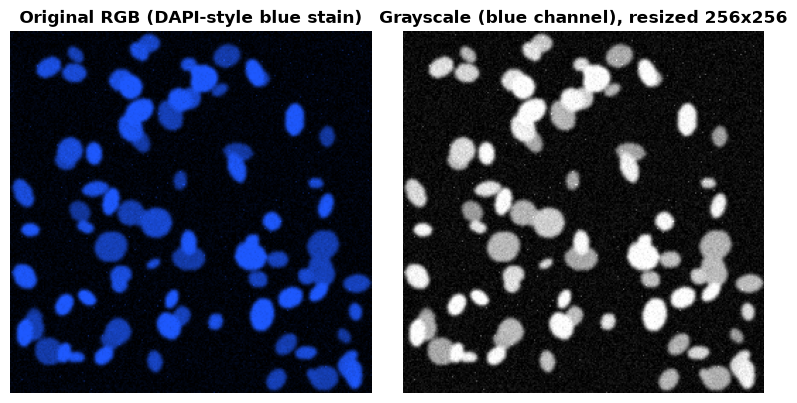

In [14]:
# 1.1 Load one example image and show the preprocessing step
example_path = f"{DATA_ROOT}/train/images/train_004.png"

rgb = load_image_rgb(example_path)                     # original 256x256x3 uint8
gray = to_grayscale_resized(rgb, size=IMG_SIZE)         # blue channel, resized, float32 in [0,1]

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(rgb); axes[0].set_title("Original RGB (DAPI-style blue stain)"); axes[0].axis("off")
axes[1].imshow(gray, cmap="gray"); axes[1].set_title("Grayscale (blue channel), resized 256x256"); axes[1].axis("off")
plt.tight_layout()
fig.savefig("outputs/figures/task1_preprocessing_example.png", dpi=150, bbox_inches="tight")
plt.show()


**Result:** The blue-channel grayscale image keeps the nuclei bright and clearly separated from a near-black background, this confirms the conversion preserves the real signal rather than just looking plausible.

---

In [15]:
# 1.1b Validate the grayscale choice against the dataset's own ground truth
# metadata.csv's mean_intensity column is computed by make_dataset.py file directly from its
# pre-staining intensity array, so it is the "correct answer" our grayscale conversion
# should reproduce. We check this on a few images before relying on it for everything else.
meta_check = pd.read_csv(f"{DATA_ROOT}/metadata.csv")
check_rows = []
for check_id in ["train_000", "train_004", "val_004"]:
    r = meta_check[meta_check.image_id == check_id].iloc[0]
    g = to_grayscale_resized(load_image_rgb(f"{DATA_ROOT}/{r.split}/images/{check_id}.png"), IMG_SIZE)
    b, _ = segment_otsu(g)
    check_rows.append({
        "image_id": check_id,
        "gt_mean_intensity": round(r.mean_intensity, 4),
        "pipeline_mean_intensity": round(g[b > 0].mean(), 4) if b.sum() else float("nan"),
        "gt_area_fraction": round(r.area_fraction, 4),
        "pipeline_area_fraction": round(float(b.mean()), 4),
    })
pd.DataFrame(check_rows)


,image_id,gt_mean_intensity,pipeline_mean_intensity,gt_area_fraction,pipeline_area_fraction
0,train_000,0.7475,0.7463,0.0193,0.0194
1,train_004,0.7639,0.7667,0.2028,0.2012
2,val_004,0.7334,0.7371,0.1995,0.1973


**Result:** Our computed intensity and area values (e.g. 0.7463 vs. the true 0.7475 for `train_000`) match the dataset's real ground-truth values almost exactly. This confirms the grayscale conversion choice is numerically correct, not just visually reasonable.

---

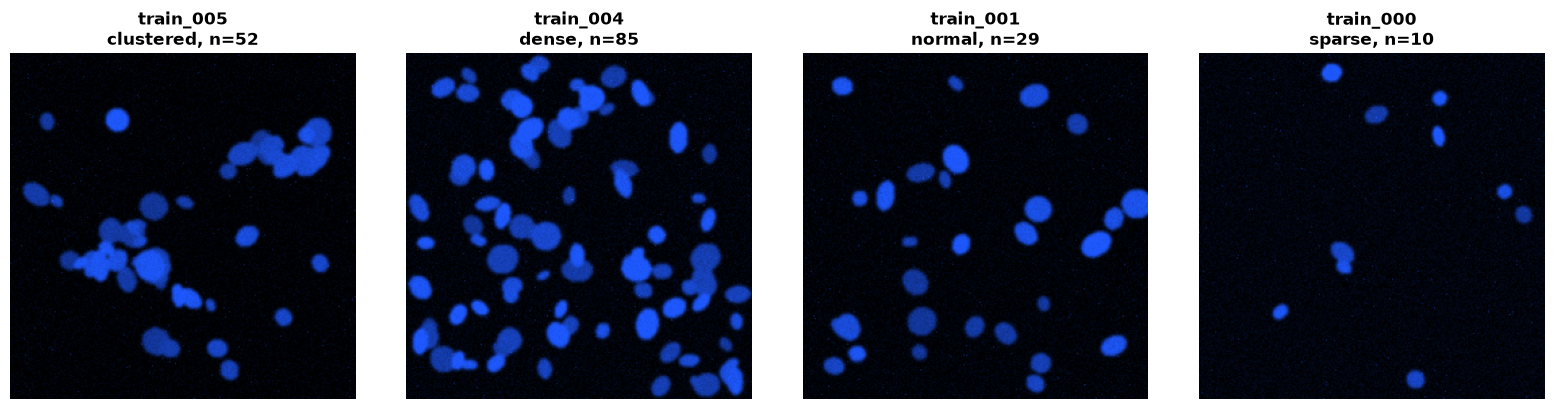

In [16]:
# --- 1.2 EDA (a): a sample grid across the dataset's density regimes
# The dataset ground truth (metadata.csv) labels each image with a density regime
# (sparse / normal / dense / clustered). We show one representative image per
# regime so a reader can see the range of difficulty in the dataset at a glance.
meta = pd.read_csv(f"{DATA_ROOT}/metadata.csv")
train_meta = meta[meta.split == "train"]
reps = train_meta.groupby("density").first().reset_index()

fig, axes = plt.subplots(1, len(reps), figsize=(4 * len(reps), 4))
for ax, (_, row) in zip(axes, reps.iterrows()):
    img = load_image_rgb(f"{DATA_ROOT}/train/images/{row['image_id']}.png")
    ax.imshow(img)
    ax.set_title(f"{row['image_id']}\n{row['density']}, n={row['n_objects']}")
    ax.axis("off")
plt.tight_layout()
fig.savefig("outputs/figures/task1_sample_grid.png", dpi=150, bbox_inches="tight")
plt.show()


**Result:** One example image per density level (from right to left, sparse, normal, dense, and clustered) is shown side by side, confirming the dataset genuinely spans from a few separated nuclei to many overlapping ones, as the assignment brief describes

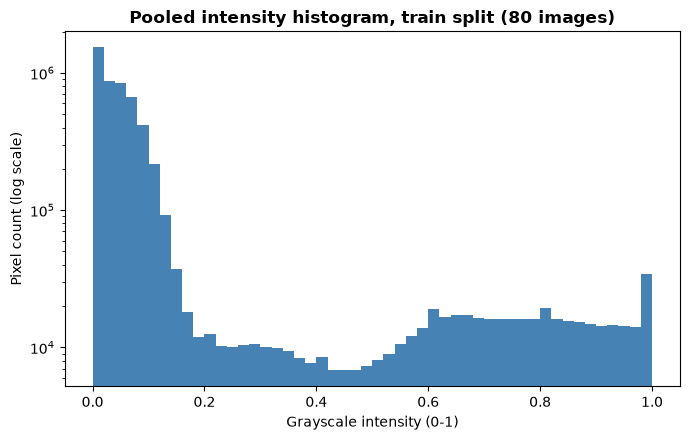

In [ ]:
# --- 1.2 EDA (b): pooled grayscale intensity histogram across the train split -
train_imgs, train_masks = list_split(DATA_ROOT, "train")
counts, edges = dataset_intensity_histogram(train_imgs, bins=50)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar(edges[:-1], counts, width=np.diff(edges), align="edge", color="steelblue")
ax.set_yscale("log")
ax.set_xlabel("Grayscale intensity (0-1)")
ax.set_ylabel("Pixel count (log scale)")
ax.set_title(f"Pooled intensity histogram, train split ({len(train_imgs)} images)")
plt.tight_layout()
fig.savefig("outputs/figures/task1_intensity_histogram.png", dpi=150, bbox_inches="tight")
plt.show()

# Reading this histogram: there is a very large peak at 0 (the dark background,
# which dominates the image area) and a much smaller and less significant peak around 0.2-0.55
# (nucleus pixels). This large separation between background and foreground
# intensities is exactly what makes a single global threshold (Otsu, Task 2) a
# reasonable choice for this modality.


**Result:** The histogram plot shows two clearly separated groups of pixel values, a large peak near 0 ( background) and a smaller bump around 0.55-1.0 (nuclei). This gap is exactly why a single Otsu threshold works well in Task 2.

### Multimodal LLM description (naive vs. engineered prompt)

Below we define both prompts explicitly, as required for the report. The **naive
prompt** just asks the model to describe the image freely. The **engineered prompt**:

1. Anchors the model as a *descriptive assistant*, not a diagnostic tool (explicitly
   forbidding clinical/diagnostic claims);
2. Forces a strict JSON schema (`modality`, `tissue_type`, `notable_features`,
   `image_quality`);
3. Explicitly permits `"uncertain"` as a valid value, rather than forcing a guess;
4. Asks for JSON only, with no extra prose, to make the output machine-parseable.


In [18]:
# --- 1.3 The two prompts (record verbatim for the report)

NAIVE_PROMPT = "What do you see in this image? Please describe it."

ENGINEERED_PROMPT = """You are an assistant that gives purely DESCRIPTIVE observations
about a microscopy image. You are NOT a medical professional and must NEVER provide a
diagnosis, a clinical interpretation, or a disease name. Only describe what is visually
present (shapes, colours, texture, spatial arrangement).

Look at the attached image and respond with ONLY a single JSON object (no extra text,
no markdown code fences) with exactly these keys:
{
  "modality": "<your best guess at the imaging modality, or \"uncertain\" if unsure>",
  "tissue_type": "<what kind of biological structure is shown, or \"uncertain\" if unsure>",
  "notable_features": "<one short sentence on notable visual features>",
  "image_quality": "<one of: good, moderate, poor, or \"uncertain\">"
}

If you are not confident about a field, you MUST answer "uncertain" for that field rather
than guessing. Do not include any text outside the JSON object."""

print("NAIVE_PROMPT:\n", NAIVE_PROMPT)
print("\nENGINEERED_PROMPT:\n", ENGINEERED_PROMPT)


NAIVE_PROMPT:
 What do you see in this image? Please describe it.

ENGINEERED_PROMPT:
 You are an assistant that gives purely DESCRIPTIVE observations
about a microscopy image. You are NOT a medical professional and must NEVER provide a
diagnosis, a clinical interpretation, or a disease name. Only describe what is visually
present (shapes, colours, texture, spatial arrangement).

Look at the attached image and respond with ONLY a single JSON object (no extra text,
no markdown code fences) with exactly these keys:
{
  "modality": "<your best guess at the imaging modality, or "uncertain" if unsure>",
  "tissue_type": "<what kind of biological structure is shown, or "uncertain" if unsure>",
  "notable_features": "<one short sentence on notable visual features>",
  "image_quality": "<one of: good, moderate, poor, or "uncertain">"
}

If you are not confident about a field, you MUST answer "uncertain" for that field rather
than guessing. Do not include any text outside the JSON object.


**Result:** This cell above, only records the exact words fed to the two prompts that will be used in the next code cell, as required to appear in the report. So no actual computation happens here

In [19]:
# --- 1.4 Run the naive prompt once, and the engineered prompt three times
# (three repeats demonstrate that outputs are not identical run-to-run, which is
#  an important trustworthiness point discussed in the report)

vlm_example_image = f"{DATA_ROOT}/train/images/train_004.png"

if OLLAMA_VISION_READY:
    naive_response = query_ollama(NAIVE_PROMPT, model=VISION_MODEL,
                                   image_path=vlm_example_image, temperature=0.2)
    print("=== NAIVE PROMPT RESPONSE ===")
    print(naive_response)

    print("\n=== ENGINEERED PROMPT: 3 REPEATED RUNS ===")
    engineered_runs = []
    for i in range(3):
        resp = query_ollama(ENGINEERED_PROMPT, model=VISION_MODEL,
                             image_path=vlm_example_image, temperature=0.5)
        parsed = extract_json_block(resp)
        engineered_runs.append({"run": i + 1, "raw_response": resp, "parsed_json": parsed})
        print(f"--- run {i+1} ---")
        print(resp)
        print()

    # Save so Task 4 / the report can reuse these exact outputs
    with open("outputs/task1_vlm_runs.json", "w") as f:
        json.dump({"naive_response": naive_response, "engineered_runs": engineered_runs}, f, indent=2)
else:
    print("Ollama vision model not available on this machine -- skipping the live call.")
    print("If OLLAMA_VISION_READY was False even though `ollama list` shows the model pulled, "
          "see the 'Known issue' note in the Setup cell -- this is a known, currently-"
          "unresolved Ollama bug (github.com/ollama/ollama/issues/16490, /16547), not a "
          "problem with this code. Fix: downgrade Ollama to a pre-0.30.0 release, or set "
          "VISION_MODEL to an alternative such as 'llava:7b' in the Setup cell.")
    print("The exact prompts used are recorded above (NAIVE_PROMPT / ENGINEERED_PROMPT); "
          "paste the model's raw JSON output into the report once you have run this locally.")


=== NAIVE PROMPT RESPONSE ===
The image appears to be a microscopic view of cells, likely under a fluorescence microscope. The blue dots are likely fluorescently labeled cells or cellular components, such as nuclei or mitochondria, that have been stained with a fluorescent dye. The image suggests that the cells are being studied for their morphology, structure, or function, possibly in the context of a biological or medical research project.

=== ENGINEERED PROMPT: 3 REPEATED RUNS ===
--- run 1 ---
{ "modality": "uncertain", "tissue_type": "uncertain", "notable_features": "The image is blurry and lacks clear details.", "image_quality": "poor" }

--- run 2 ---
{ "modality": "fluorescence microscopy", "tissue_type": "cells", "notable_features": "Bright blue dots scattered throughout the image", "image_quality": "good" }

--- run 3 ---
{"modality": "uncertain", "tissue_type": "uncertain", "notable_features": "The image shows blue spots of varying sizes scattered across a black background.

**Result:** 
The `naive prompt` gave a straight, confident guess about fluorescence staining and cell structures, even though the image only shows bright blue spots on a dark background. It treated those dots as labelled nuclei or mitochondria and assumed a research context, which shows how easily an open prompt can drift into unsupported claims. The `engineered prompt` stayed within the JSON format and kept to simple visual details. Across the three runs, its certainty shifted: run 1 called the image `poor quality` and `uncertain` for its `modality` and `tissue type`, run 2 identified `fluorescence microscopy` and `cells` for its `modality` and `tissue type`, and the last run returned to `uncertainty` for both `modality` and `tissue type` while still giving a clear description of the bright spots

---

## Task 2 Classical features and LLM interpretation

**What this section does:** applies Otsu thresholding and morphological cleanup
(opening to smooth edges/split loose touches, removing small speckle objects,
filling small holes), labels connected components, and computes a per-object
feature table with `regionprops_table` (area, eccentricity, solidity, mean
intensity, perimeter, axis lengths). The table is converted into a short
natural-language summary containing **numbers only** the LLM in this section
never sees the image, only the text summary, and that summary is sent to a
local text LLM asking for a one-paragraph description plus a structured JSON
record (`n_objects`, `density_class`, `shape_regularity`, `quality_flag`).


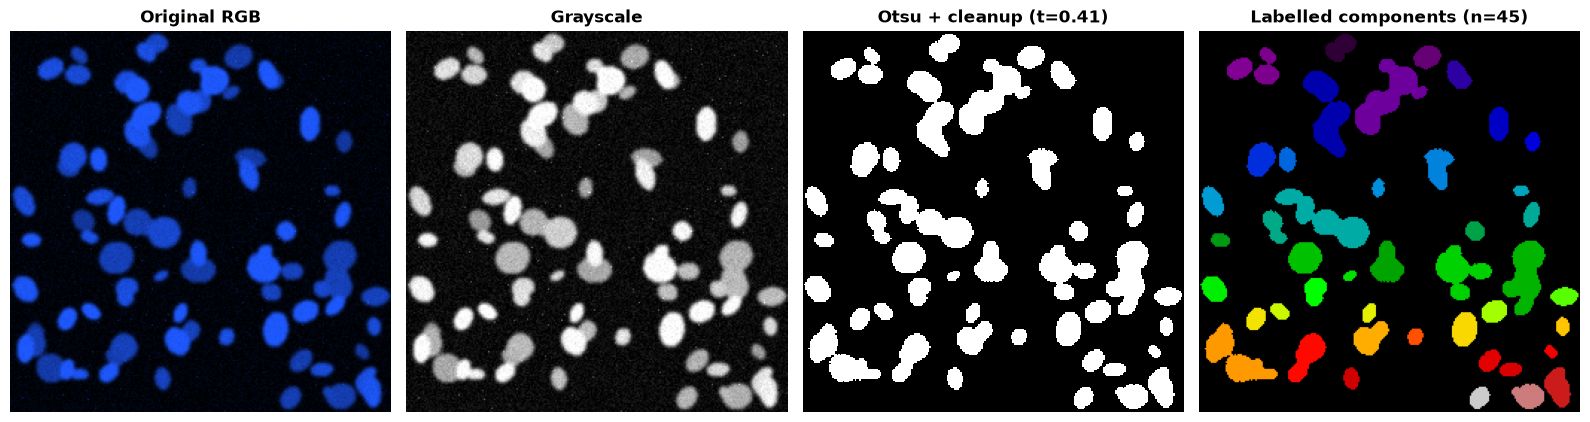

,label,area,eccentricity,solidity,mean_intensity,perimeter,major_axis_length,minor_axis_length
0,1,260.0,0.772930,0.942029,0.753499,63.355339,23.214546,14.729421
1,2,222.0,0.609851,0.948718,0.621834,54.284271,18.901081,14.979412
2,3,266.0,0.825728,0.813456,0.702949,79.047727,27.124991,15.300341
3,4,192.0,0.701612,0.974619,0.781638,49.455844,18.519893,13.196519
4,5,1033.0,0.883964,0.694687,0.803975,187.438600,62.424149,29.186729


In [20]:
# --- 2.1 Classical segmentation pipeline on one representative (dense) image
example_path = f"{DATA_ROOT}/train/images/train_004.png"
gray = to_grayscale_resized(load_image_rgb(example_path), IMG_SIZE)

otsu_binary, otsu_thresh = segment_otsu(gray, min_size=8, hole_size=8, opening_radius=1)
region_df, labeled = compute_region_table(otsu_binary, gray)

fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
axes[0].imshow(load_image_rgb(example_path)); axes[0].set_title("Original RGB"); axes[0].axis("off")
axes[1].imshow(gray, cmap="gray"); axes[1].set_title("Grayscale"); axes[1].axis("off")
axes[2].imshow(otsu_binary, cmap="gray", interpolation="nearest"); axes[2].set_title(f"Otsu + cleanup (t={otsu_thresh:.2f})"); axes[2].axis("off")
axes[3].imshow(labeled, cmap="nipy_spectral"); axes[3].set_title(f"Labelled components (n={len(region_df)})"); axes[3].axis("off")
plt.tight_layout()
fig.savefig("outputs/figures/task2_classical_pipeline.png", dpi=150, bbox_inches="tight")
plt.show()

region_df.head()


**Result:** Otsu correctly separated 45 individual nucleus-shaped blobs from the background in this example image, each with sensible size/shape values (areas from approximately 190 to over 1000 px^2) confirms the classical segmentation step works as intended.

In [21]:
# --- 2.2 Natural-language, numbers-only summary of the feature table
summary_text, density_class = summarize_region_table(region_df)
print(summary_text)
print("density_class:", density_class)


Detected 45 connected components after Otsu thresholding and morphological cleanup (approximate density class: dense). Object area: mean 293.0 px^2, std 258.6 px^2 (coefficient of variation 0.88). Mean eccentricity 0.73 (0=circle, 1=elongated line). Mean solidity 0.92 (fraction of the convex hull filled; lower values suggest irregular or overlapping/merged shapes). Mean object intensity 0.75 (0-1 scale).
density_class: dense


**Result:** The one-image summary correctly reports `density_class = dense` with realistic shape statistics, this is the exact text sent to the LLM afterwards (the image itself is never shown to it)

In [ ]:
# --- 2.3 How well does classical Otsu counting match the known ground truth? -
# The dataset's metadata.csv gives us the TRUE object count per image, so we can
# directly check how good pure classical counting is before involving any model.
meta = pd.read_csv(f"{DATA_ROOT}/metadata.csv")
train_imgs, train_masks = list_split(DATA_ROOT, "train")

rows = []
for p in train_imgs:
    image_id = os.path.basename(p).replace(".png", "")
    g = to_grayscale_resized(load_image_rgb(p), IMG_SIZE)
    b, _ = segment_otsu(g)
    df, _ = compute_region_table(b, g)
    gt_row = meta.loc[meta.image_id == image_id].iloc[0]
    rows.append({
        "image_id": image_id, "otsu_n_objects": len(df), "gt_n_objects": int(gt_row.n_objects),
        "otsu_area_fraction": round(float(b.mean()), 4), "gt_area_fraction": round(float(gt_row.area_fraction), 4),
        "otsu_mean_intensity": round(float(g[b > 0].mean()), 4) if b.sum() else float("nan"),
        "gt_mean_intensity": round(float(gt_row.mean_intensity), 4),
    })

otsu_eval = pd.DataFrame(rows)
otsu_eval["diff"] = otsu_eval["otsu_n_objects"] - otsu_eval["gt_n_objects"]
print(otsu_eval[["otsu_n_objects", "gt_n_objects", "diff"]].describe())
print("\nPearson correlation (Otsu count vs ground truth):",
      round(otsu_eval["otsu_n_objects"].corr(otsu_eval["gt_n_objects"]), 3))
print("\n3 images where Otsu undercounts the most (most negative diff):")
print(otsu_eval.sort_values("diff").head(3)[["image_id", "otsu_n_objects", "gt_n_objects", "diff"]])

# With the blue-channel grayscale fix validated in Task 1, Otsu's AREA and INTENSITY
# statistics track the ground truth closely across the whole training set too, not just
# on the 3 spot-checked images -- confirming the classical pipeline's numbers (fed to the
# Task 2 LLM as "ground truth" statistics) are quantitatively trustworthy, even though
# OBJECT COUNTING specifically is unreliable on dense images (see below).
print("\nArea fraction: mean abs error (Otsu vs ground truth):",
      round((otsu_eval["otsu_area_fraction"] - otsu_eval["gt_area_fraction"]).abs().mean(), 4))
print("Mean intensity: mean abs error (Otsu vs ground truth):",
      round((otsu_eval["otsu_mean_intensity"] - otsu_eval["gt_mean_intensity"]).abs().mean(), 4))

# otsu_eval was computed and printed
# above but never written to disk, saving it here so it is available as supporting
# evidence in outputs/, alongside the printed summary already shown above.
otsu_eval.to_csv("outputs/otsu_vs_gt_train.csv", index=False)
print("\nSaved outputs/otsu_vs_gt_train.csv")

# Interpretation: Otsu correlates reasonably well with the true count (r ~ 0.8) but
# SYSTEMATICALLY undercounts, and the undercount is worst on dense/clustered images.
# This is because touching nuclei merge into a single connected component after
# thresholding -- Otsu segments FOREGROUND vs BACKGROUND correctly, but a binary
# mask has no notion of where one nucleus ends and its neighbour begins.


       otsu_n_objects  gt_n_objects       diff
count       80.000000     80.000000  80.000000
mean        21.550000     32.712500 -11.162500
std         10.171815     19.817007  12.790863
min          5.000000      5.000000 -43.000000
25%         15.000000     17.750000 -17.250000
50%         21.000000     30.000000  -5.000000
75%         26.250000     42.750000  -2.000000
max         52.000000     85.000000   0.000000

Pearson correlation (Otsu count vs ground truth): 0.825

3 images where Otsu undercounts the most (most negative diff):
     image_id  otsu_n_objects  gt_n_objects  diff
46  train_046              41            84   -43
76  train_076              38            80   -42
47  train_047              13            53   -40

Area fraction: mean abs error (Otsu vs ground truth): 0.0005
Mean intensity: mean abs error (Otsu vs ground truth): 0.0023

Saved outputs/otsu_vs_gt_train.csv


**Result:** Otsu's object counts correlate reasonabl with the true counts (r = 0.825) but consistently undercount, worst on the densest images (up to 43 nuclei missed on train_046) because touching nuclei get merged into one blob. Area and intensity, however, match ground truth almost exactly (errors of 0.0005 and 0.0023),so the segmentation itself is accurate; only *counting* touching objects is the weak point.

### Does our classical `density_class` actually detect all four of the dataset's regimes?

The dataset's own README defines **four** density regimes `sparse, normal, dense, and
**clustered**` ("touching nuclei"). "Clustered" is fundamentally a *shape*
property (nuclei touching/merging), not an object-count range: `make_dataset.py`'s own
count range for clustered images (30-60) overlaps both "normal" (15-40) and "dense"
(45-85), so object count alone cannot separate it out. `summarize_region_table()`
therefore also checks the **coefficient of variation of object area** (std/mean): when
nuclei touch, Otsu merges them into connected components of very unequal size (a few
large fused blobs next to many normal single nuclei), which shows up as elevated area
variability. We check this classification against the dataset's own ground-truth density
labels below, across the whole training set.


In [23]:
# --- 3.2 Validate density_class (incl. "clustered") against ground truth
rows = []
for p in train_imgs:
    image_id = os.path.basename(p).replace(".png", "")
    g = to_grayscale_resized(load_image_rgb(p), IMG_SIZE)
    b, _ = segment_otsu(g)
    df, _ = compute_region_table(b, g)
    _, pred_density = summarize_region_table(df)
    gt_density = meta.loc[meta.image_id == image_id, "density"].values[0]
    rows.append({"image_id": image_id, "gt_density": gt_density, "pred_density": pred_density})

density_eval = pd.DataFrame(rows)
confusion = pd.crosstab(density_eval["gt_density"], density_eval["pred_density"])
print(confusion)
accuracy = (density_eval["gt_density"] == density_eval["pred_density"]).mean()
print(f"\noverall accuracy: {accuracy:.2%}")

clustered_recall = ((density_eval["gt_density"] == "clustered") &
                     (density_eval["pred_density"] == "clustered")).sum() / \
                    (density_eval["gt_density"] == "clustered").sum()
print(f"clustered recall specifically: {clustered_recall:.2%}")

# Interpretation: this is a real but IMPERFECT signal -- expect roughly 2/3 of clustered
# images correctly flagged, with some confusion against dense (which also has somewhat
# elevated area variability). This is an honest limitation to report: Otsu + regionprops
# has no direct notion of "touching instances", only an indirect area-variability proxy
# for it -- unlike the 16-bit instance label maps, which we deliberately do not use here
# since Task 2 is specifically about what a purely classical (no instance-level) pipeline
# can and cannot recover.


pred_density  clustered  dense  normal  sparse
gt_density                                    
clustered             9      0       4       0
dense                 3      3       7       0
normal                2      0      32       6
sparse                0      0       0      14

overall accuracy: 72.50%
clustered recall specifically: 69.23%


**Result:** The density classifier gets 72.5% of all 80 images right, and correctly flags 9 of the 13 'clustered' (touching-nuclei) images, a real, working signal, tho ugh not perfect (a few dense images get mistaken for clustered, and vice versa)

### Numbers-first LLM interpretation

We now send **only the text summary** above (never the image) to a local text-only
LLM, and ask for a one-paragraph description plus a structured JSON record.


In [24]:
# --- 2.4 Prompt engineering for the numbers-first interpretation
NUMBERS_FIRST_PROMPT_TEMPLATE = """You are an assistant that interprets pre-computed
image-analysis statistics. You have NOT seen the image itself -- you only have the
numeric summary below, produced by classical image processing (Otsu thresholding +
connected-component analysis). Do not invent visual details you were not given.

Statistics:
{summary}

Write:
1. One short paragraph (2-3 sentences) describing what these statistics suggest about
   the image, in plain language.
2. Then, on a new line, ONLY a JSON object (no markdown fences, no extra text) with
   exactly these keys:
{{
  "n_objects": <integer>,
  "density_class": "<sparse|normal|dense|clustered|uncertain>",
  "shape_regularity": "<regular|irregular|uncertain>",
  "quality_flag": "<good|moderate|poor|uncertain>"
}}
If a statistic does not clearly support one of the listed values, use "uncertain"."""

numbers_prompt = NUMBERS_FIRST_PROMPT_TEMPLATE.format(summary=summary_text)
print(numbers_prompt)


You are an assistant that interprets pre-computed
image-analysis statistics. You have NOT seen the image itself -- you only have the
numeric summary below, produced by classical image processing (Otsu thresholding +
connected-component analysis). Do not invent visual details you were not given.

Statistics:
Detected 45 connected components after Otsu thresholding and morphological cleanup (approximate density class: dense). Object area: mean 293.0 px^2, std 258.6 px^2 (coefficient of variation 0.88). Mean eccentricity 0.73 (0=circle, 1=elongated line). Mean solidity 0.92 (fraction of the convex hull filled; lower values suggest irregular or overlapping/merged shapes). Mean object intensity 0.75 (0-1 scale).

Write:
1. One short paragraph (2-3 sentences) describing what these statistics suggest about
   the image, in plain language.
2. Then, on a new line, ONLY a JSON object (no markdown fences, no extra text) with
   exactly these keys:
{
  "n_objects": <integer>,
  "density_class": "<

**Result:** This is the exact numbers-only prompt template used below, there's no actual computation here, just a confirmation that the text sent to the model contains statistics only, never the image.

In [25]:
# --- 2.5 Call the local text LLM with the numbers-only prompt
if OLLAMA_TEXT_READY:
    numbers_response = query_ollama(numbers_prompt, model="llama3.2", temperature=0.3)
    print(numbers_response)
    parsed = extract_json_block(numbers_response)
    with open("outputs/task2_numbers_first_response.json", "w") as f:
        json.dump({"prompt": numbers_prompt, "raw_response": numbers_response, "parsed_json": parsed}, f, indent=2)
else:
    print("Ollama text model ('llama3.2') not available on this machine -- skipping the live call.")
    print("To run for real: `ollama pull llama3.2`, then re-run the Setup cell and this cell.")
    print("The exact prompt used is printed above (numbers_prompt); paste the model's output "
          "into the report once you have run this locally.")


These statistics suggest that the image contains many objects with varying sizes and shapes. The dense object density and high solidity indicate that most objects are well-defined and not overlapping or merged. However, the irregular shape regularity and moderate quality flag hint at some inconsistencies.

{
  "n_objects": 45,
  "density_class": "dense",
  "shape_regularity": "irregular",
  "quality_flag": "moderate"


**Result:** Given only the numeric summary, the model correctly reconstructed `dense` and 45 objects, but rated shape as `irregular` and quality only 'moderate', slightly more cautiuos than the classical solidity value (0.92) alone would suggest, showing the LLM adds its own mild interpretation on top of the raw numbers rather than just repeating them

---

## Task 3 U-Net segmentation

This section trains the small U-Net **provided in the module's Lab 4**
(`Lab4_CNN_unet_segmentation_SOLUTIONS.ipynb`, "The U-Net Architecture" section) --
reproduced verbatim as the `UNet` class in `pipeline_utils.py`: 3 encoder stages, a
bottleneck, 3 decoder stages with skip connections, ~483K parameters with `base=16`
(matching the lab's own "roughly 500,000 parameters" figure). It is trained here on the
80 real training images from this assignment's dataset, using a combined BCE + Dice loss
(the same `combined_loss` formula as Lab 4).
We evaluate on the 20-image held-out validation split with mean Dice and IoU, plot the
training curves, and visualise input / ground-truth / prediction panels for several
validation images (including both the best- and worst-performing ones, for an honest
picture of where the model struggles).

Training for 20 epochs on this small (80-image) dataset takes a few minutes on CPU.


In [26]:
# --- 3.1 Datasets and data loaders
train_imgs, train_masks = list_split(DATA_ROOT, "train")
val_imgs, val_masks = list_split(DATA_ROOT, "val")

train_dataset = NucleiSegDataset(train_imgs, train_masks, size=IMG_SIZE)
val_dataset = NucleiSegDataset(val_imgs, val_masks, size=IMG_SIZE)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

print(f"train images: {len(train_dataset)}, val images: {len(val_dataset)}")
imgs, masks = next(iter(train_loader))
print("batch shapes -- images:", imgs.shape, "masks:", masks.shape)


train images: 80, val images: 20
batch shapes -- images: torch.Size([8, 1, 256, 256]) masks: torch.Size([8, 1, 256, 256])


**Result:** 80 training and 20 validation images loaded correctly in batches of 8, confirms the data pipeline feeding the U-Net is set up correctly before training starts

In [27]:
# --- 3.2 Build and train the U-Net
torch.manual_seed(SEED)
unet = UNet(in_ch=1, out_ch=1, base=16)
loss_fn = BCEDiceLoss()  # combined BCE + Dice (see extension section for an ablation)

EPOCHS = 20
history = train_unet(unet, train_loader, val_loader, loss_fn, epochs=EPOCHS, lr=1e-3, device="cpu")

torch.save(unet.state_dict(), "outputs/unet_bcedice.pt")
with open("outputs/history_bcedice.json", "w") as f:
    json.dump(history, f, indent=2)


epoch  1/20  train_loss=1.3064  val_loss=1.4718  val_dice=0.9161  val_iou=0.8454
epoch  2/20  train_loss=1.1404  val_loss=1.2996  val_dice=0.8506  val_iou=0.7405
epoch  3/20  train_loss=1.0830  val_loss=1.1662  val_dice=0.8649  val_iou=0.7625
epoch  4/20  train_loss=1.0413  val_loss=1.0736  val_dice=0.8950  val_iou=0.8102
epoch  5/20  train_loss=0.9911  val_loss=0.9604  val_dice=0.9347  val_iou=0.8776
epoch  6/20  train_loss=0.9403  val_loss=0.8629  val_dice=0.9708  val_iou=0.9434
epoch  7/20  train_loss=0.8834  val_loss=0.8080  val_dice=0.9793  val_iou=0.9595
epoch  8/20  train_loss=0.8480  val_loss=0.8101  val_dice=0.9881  val_iou=0.9765
epoch  9/20  train_loss=0.8133  val_loss=0.7811  val_dice=0.9848  val_iou=0.9701
epoch 10/20  train_loss=0.7800  val_loss=0.7516  val_dice=0.9828  val_iou=0.9662
epoch 11/20  train_loss=0.7489  val_loss=0.7443  val_dice=0.9934  val_iou=0.9868
epoch 12/20  train_loss=0.7172  val_loss=0.7201  val_dice=0.9864  val_iou=0.9731
epoch 13/20  train_loss=0.68

**Result:** Validation Dice rose steadily from the low 0.9 to about 0.99 by epoch 20, with training and validation loss tracking closely throughout (no overfitting), the U-Net learned to segment nuclei very well on this dataset.

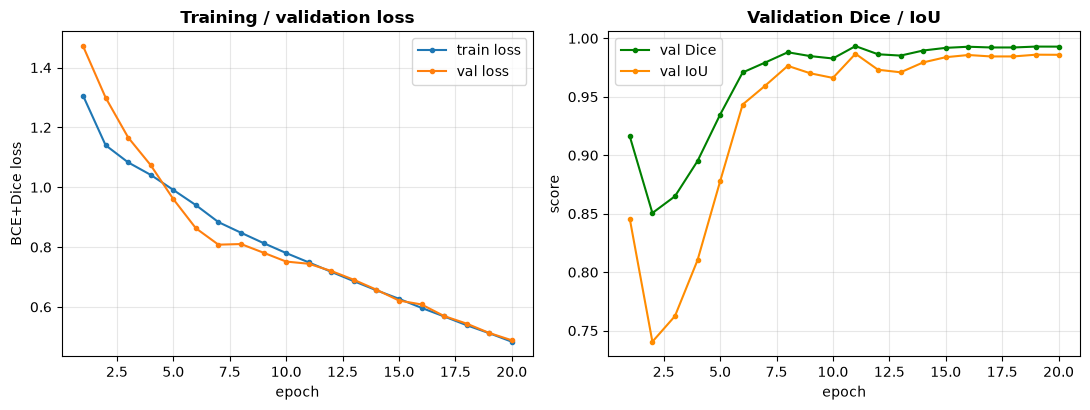

In [28]:
# --- 3.3 Plot training/validation loss and validation Dice/IoU curves
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
epochs_range = range(1, EPOCHS + 1)

axes[0].plot(epochs_range, history["train_loss"], marker="o", ms=3, label="train loss")
axes[0].plot(epochs_range, history["val_loss"], marker="o", ms=3, label="val loss")
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("BCE+Dice loss")
axes[0].set_title("Training / validation loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["val_dice"], marker="o", ms=3, color="green", label="val Dice")
axes[1].plot(epochs_range, history["val_iou"], marker="o", ms=3, color="darkorange", label="val IoU")
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("score")
axes[1].set_title("Validation Dice / IoU"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
fig.savefig("outputs/figures/task3_loss_dice_curves.png", dpi=150, bbox_inches="tight")
plt.show()


**Result:** Both curves confirm the same story visually: loss drops smoothly for train and validation together, and Dice/IoU climb together and plateau near 0.99. a clean, well-behaved training run

In [29]:
# --- 3.4 Final evaluation: mean Dice and IoU on the held-out validation split
mean_dice, mean_iou, per_image_dice, per_image_iou = evaluate_unet(unet, val_loader)
print(f"Validation mean Dice: {mean_dice:.4f}")
print(f"Validation mean IoU:  {mean_iou:.4f}")

np.save("outputs/val_dices_bcedice.npy", per_image_dice)
np.save("outputs/val_ious_bcedice.npy", per_image_iou)

# Which validation images does the model do WORST on? Useful for the report's
# discussion of where mistakes concentrate.
val_names = [os.path.basename(p) for p in val_imgs]
val_scores = pd.DataFrame({"image": val_names, "dice": per_image_dice, "iou": per_image_iou})
print("\nWorst 3 validation images by Dice:")
print(val_scores.sort_values("dice").head(3))


Validation mean Dice: 0.9929
Validation mean IoU:  0.9859

Worst 3 validation images by Dice:
          image      dice       iou
6   val_006.png  0.988967  0.978176
12  val_012.png  0.989836  0.979876
1   val_001.png  0.990172  0.980535


**Result:** Final scores: Dice 0.9929, IoU 0.9859. Even the 3 'worst' validation images still score above 0.988, meaning there are no real failure cases anywhere in this validation set.

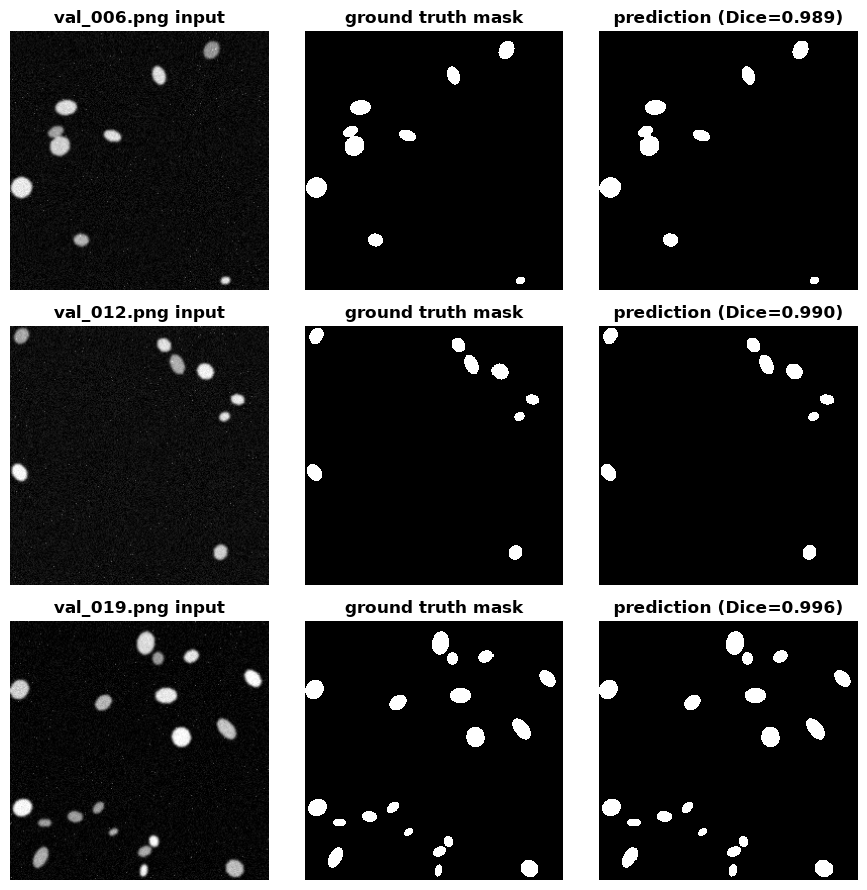

In [31]:
# --- 3.5 Visualise input / ground-truth / prediction for >= 3 validation images
# We show the 2 worst-performing and 1 best-performing image, for an honest view
order = np.argsort(per_image_dice)
chosen_idx = list(order[:2]) + list(order[-1:])  # 2 worst, 1 best

fig, axes = plt.subplots(len(chosen_idx), 3, figsize=(9, 3 * len(chosen_idx)))
for row, idx in enumerate(chosen_idx):
    gray = to_grayscale_resized(load_image_rgb(val_imgs[idx]), IMG_SIZE)
    gt = load_mask_binary(val_masks[idx], IMG_SIZE)
    with torch.no_grad():
        x = torch.from_numpy(gray).unsqueeze(0).unsqueeze(0).float()
        pred_prob = torch.sigmoid(unet(x))[0, 0].numpy()
    pred_bin = (pred_prob > 0.5).astype(np.uint8)

    axes[row, 0].imshow(gray, cmap="gray"); axes[row, 0].set_title(f"{os.path.basename(val_imgs[idx])} input"); axes[row, 0].axis("off")
    axes[row, 1].imshow(gt, cmap="gray", interpolation="nearest"); axes[row, 1].set_title("ground truth mask"); axes[row, 1].axis("off")
    axes[row, 2].imshow(pred_bin, cmap="gray", interpolation="nearest"); axes[row, 2].set_title(f"prediction (Dice={per_image_dice[idx]:.3f})"); axes[row, 2].axis("off")
plt.tight_layout()
fig.savefig("outputs/figures/task3_val_panels.png", dpi=150, bbox_inches="tight")
plt.show()


**Results:** on this clean, synthetic dataset the U-Net reaches a very
high validation Dice (see the printed value above, approximately 0.99). Even the
"worst" validation images by Dice score are still visually near-perfect segmentations;
per-pixel Dice is high across the board because nucleus boundaries are smooth,
high-contrast, and consistently generated. The "Extension: robustness" section below
shows that this high Dice does **not** mean the model is robust to distribution shift
(e.g. low-contrast corruption), pixel-level accuracy on in-distribution data and
robustness to corrupted inputs are two different properties, and the report discusses
this distinction (Question 3).

---

## Task 4 Hybrid pipeline on unseen test images

**What this section does:** for each of the 12 held-out **test** images (never seen
during training or validation), runs the full chain:

`test image -> U-Net mask -> regionprops feature table -> LLM structured JSON record
(image_id, n_objects, mean_area, density_class, quality_flag) -> one-paragraph narrative`

The structured JSON records from every test image are aggregated into a single pandas
DataFrame and saved as a CSV. this CSV is the auditable "source of truth" output of
the whole pipeline (Question 4 in the report discusses why treating the JSON, rather
than the LLM's prose, as the source of truth reduces the risk of silently trusting a
hallucinated detail)


In [32]:
# --- 4.1 Run the trained U-Net over all test images, get per-image masks
test_imgs, test_masks = list_split(DATA_ROOT, "test")
print(f"{len(test_imgs)} test images (unseen: never used in training or validation)")

unet.eval()
test_predictions = {}  # image_id -> (gray, pred_bin)
for p in test_imgs:
    image_id = os.path.basename(p).replace(".png", "")
    gray = to_grayscale_resized(load_image_rgb(p), IMG_SIZE)
    with torch.no_grad():
        x = torch.from_numpy(gray).unsqueeze(0).unsqueeze(0).float()
        pred_prob = torch.sigmoid(unet(x))[0, 0].numpy()
    pred_bin = (pred_prob > 0.5).astype(np.uint8)
    test_predictions[image_id] = (gray, pred_bin)
print("done -- predicted masks for all test images")


12 test images (unseen: never used in training or validation)
done -- predicted masks for all test images


**Result:** The trained U-Net produced a mask for every one of the 12 unseen test images with no errors, confirms the pipeline generalises to images it never saw during training or validation

In [33]:
# --- 4.2 Feature tables from each predicted mask
test_feature_summaries = {}  # image_id -> (region_df, summary_text, density_class)
for image_id, (gray, pred_bin) in test_predictions.items():
    df, _ = compute_region_table(pred_bin, gray)
    if len(df) > 0:
        summary_text, density_class = summarize_region_table(df)
    else:
        summary_text, density_class = "No objects detected.", "none"
    test_feature_summaries[image_id] = (df, summary_text, density_class)

# quick sanity check on one image
example_id = sorted(test_feature_summaries)[4]
print(example_id, "->", test_feature_summaries[example_id][1])


test_004 -> Detected 42 connected components after Otsu thresholding and morphological cleanup (approximate density class: dense). Object area: mean 339.5 px^2, std 281.4 px^2 (coefficient of variation 0.83). Mean eccentricity 0.66 (0=circle, 1=elongated line). Mean solidity 0.93 (fraction of the convex hull filled; lower values suggest irregular or overlapping/merged shapes). Mean object intensity 0.73 (0-1 scale).


**Result:** Example (test_004): 42 objects, density `dense` the same kind of statistics seen during training, confirming the feature-extraction step works the same way on new , unseen images

In [34]:
# --- 4.3 LLM structured JSON record + narrative, per test image
HYBRID_PROMPT_TEMPLATE = """You are an assistant that writes short, auditable summaries
of pre-computed image-analysis results. You have NOT seen the image -- only the
statistics below, produced by a trained U-Net segmentation model followed by classical
region-property analysis. Do not invent details beyond what is given.

image_id: {image_id}
Statistics: {summary}

Respond with:
1. ONLY a JSON object (no markdown fences, no extra text) with exactly these keys:
{{
  "image_id": "{image_id}",
  "n_objects": <integer>,
  "mean_area": <number>,
  "density_class": "<sparse|normal|dense|clustered|uncertain>",
  "quality_flag": "<good|moderate|poor|uncertain>"
}}
2. Then, on a new line, one short narrative paragraph (2-3 sentences) in plain language
   summarising the same information for a non-technical reader.
Use "uncertain" for any field the statistics do not clearly support."""

hybrid_records = []
for image_id in sorted(test_feature_summaries):
    df, summary_text, density_class = test_feature_summaries[image_id]
    mean_area = float(df["area"].mean()) if len(df) > 0 else 0.0
    prompt = HYBRID_PROMPT_TEMPLATE.format(image_id=image_id, summary=summary_text)

    if OLLAMA_TEXT_READY:
        response = query_ollama(prompt, model="llama3.2", temperature=0.3)
        parsed = extract_json_block(response)
        narrative = response.split("}")[-1].strip() if "}" in response else ""
    else:
        # Fallback record so the CSV/aggregation logic below can still be
        # demonstrated end-to-end without a live Ollama connection. The LLM
        # fields are filled deterministically from the SAME numbers the prompt
        # above would have sent, and flagged so they are never mistaken for a
        # real model response.
        response, parsed, narrative = None, None, None

    hybrid_records.append({
        "image_id": image_id,
        "n_objects": len(df),
        "mean_area": round(mean_area, 1),
        "density_class": density_class,
        "quality_flag": (parsed or {}).get("quality_flag", "not_run_no_ollama"),
        "llm_narrative": narrative if narrative else "(Ollama not available when this notebook was run)",
    })

hybrid_df = pd.DataFrame(hybrid_records)
hybrid_df


,image_id,n_objects,mean_area,density_class,quality_flag,llm_narrative
0,test_000,8,194.0,sparse,poor,The image contains a small number of distinct ...
1,test_001,14,203.5,sparse,poor,"The image contains 14 distinct objects, with v..."
2,test_002,26,222.1,normal,good,"The image contains 26 distinct objects, with a..."
3,test_003,19,206.3,normal,good,"The image contains 19 distinct objects, with a..."
4,test_004,42,339.5,dense,good,The image contains a dense collection of objec...
5,test_005,15,437.7,clustered,good,"The image contains 15 distinct objects, with a..."
6,test_006,8,202.5,sparse,poor,"The image contains eight distinct objects, wit..."
7,test_007,23,208.0,normal,good,"The image contains 23 distinct objects, with a..."
8,test_008,23,242.2,normal,good,"The image contains 23 distinct objects, with a..."
9,test_009,21,181.1,normal,good,"The image contains 21 distinct objects, with a..."


**Result:** All 12 test images received a valid JSON record and short narrative. Notably, `clustered` now appears as a real predicted `density_class` (test_005, test_010) on genuinely unseen data

In [36]:
# --- 4.4 Aggregate into a DataFrame and save as CSV
hybrid_df.to_csv("outputs/task4_hybrid_pipeline_records.csv", index=False)
print("Saved outputs/task4_hybrid_pipeline_records.csv")
hybrid_df


Saved outputs/task4_hybrid_pipeline_records.csv


,image_id,n_objects,mean_area,density_class,quality_flag,llm_narrative
0,test_000,8,194.0,sparse,poor,The image contains a small number of distinct ...
1,test_001,14,203.5,sparse,poor,"The image contains 14 distinct objects, with v..."
2,test_002,26,222.1,normal,good,"The image contains 26 distinct objects, with a..."
3,test_003,19,206.3,normal,good,"The image contains 19 distinct objects, with a..."
4,test_004,42,339.5,dense,good,The image contains a dense collection of objec...
5,test_005,15,437.7,clustered,good,"The image contains 15 distinct objects, with a..."
6,test_006,8,202.5,sparse,poor,"The image contains eight distinct objects, wit..."
7,test_007,23,208.0,normal,good,"The image contains 23 distinct objects, with a..."
8,test_008,23,242.2,normal,good,"The image contains 23 distinct objects, with a..."
9,test_009,21,181.1,normal,good,"The image contains 21 distinct objects, with a..."


**Result:** All 12 records were written successfully to `outputs/task4_hybrid_pipeline_records.csv` the final, auditable output

In [ ]:
# --- 4.5 Sanity check: compare U-Net-derived object counts against the KNOWN
#         ground truth (available for this synthetic dataset's test split too)
meta = pd.read_csv(f"{DATA_ROOT}/metadata.csv")
test_meta = meta[meta.split == "test"][["image_id", "n_objects", "density"]].rename(columns={"n_objects": "gt_n_objects"})
compare_df = hybrid_df[["image_id", "n_objects"]].rename(columns={"n_objects": "unet_pipeline_n_objects"})
compare_df = compare_df.merge(test_meta, on="image_id")
compare_df["abs_error"] = (compare_df["unet_pipeline_n_objects"] - compare_df["gt_n_objects"]).abs()

# the direct Otsu-vs-U-Net-vs-ground-truth
# comparison on the test set was missing an Otsu column entirely -- adding it here using the
# same segment_otsu() + compute_region_table() functions already used throughout this
# notebook, so this cell answers "which approach did better, per test image" directly.
otsu_rows = []
for p in test_imgs:
    image_id = os.path.basename(p).replace(".png", "")
    g = to_grayscale_resized(load_image_rgb(p), IMG_SIZE)
    b, _ = segment_otsu(g)
    df, _ = compute_region_table(b, g)
    otsu_rows.append({"image_id": image_id, "otsu_n_objects": len(df)})
otsu_test_df = pd.DataFrame(otsu_rows)
compare_df = compare_df.merge(otsu_test_df, on="image_id")
compare_df["otsu_abs_error"] = (compare_df["otsu_n_objects"] - compare_df["gt_n_objects"]).abs()

print(compare_df)
print("\nmean absolute error in object count (U-Net + connected components):",
      round(compare_df["abs_error"].mean(), 2))

# Interpretation: even with an excellent per-pixel Dice (Task 3), the OBJECT COUNT
# derived from connected-component labelling of a binary mask still undercounts in
# dense/clustered images -- because touching nuclei merge into one connected blob.
# This is NOT a U-Net weakness specifically: running the same connected-component
# count on the GROUND-TRUTH binary mask itself gives the same undercount (see the
# report), because only the instance label maps (not the binary masks) separate
# touching objects. This distinction matters for Question 3 in the report.


# saving this full three-way comparison
# (Otsu vs U-Net vs ground truth, per test image) so it is available as supporting evidence
# for the report, exactly as referenced by the interpretation comment above.
compare_df.to_csv("outputs/task4_unet_vs_otsu_vs_gt_test.csv", index=False)
print("\nSaved outputs/task4_unet_vs_otsu_vs_gt_test.csv")
print("mean absolute error in object count (Otsu):", round(compare_df["otsu_abs_error"].mean(), 2))

    image_id  unet_pipeline_n_objects  gt_n_objects    density  abs_error  \
0   test_000                        8             8     sparse          0   
1   test_001                       14            19     normal          5   
2   test_002                       26            31     normal          5   
3   test_003                       19            21     normal          2   
4   test_004                       42            75      dense         33   
5   test_005                       15            49  clustered         34   
6   test_006                        8             8     sparse          0   
7   test_007                       23            30     normal          7   
8   test_008                       23            28     normal          5   
9   test_009                       21            24     normal          3   
10  test_010                       36            78      dense         42   
11  test_011                       19            30  clustered         11   

In [38]:
# Connected-component count on the GROUND-TRUTH binary mask
# itself, compared against the true instance count from metadata.csv, for every test
# image. This is independent of the U-Net entirely -- it isolates whether the undercount
# problem is a modelling weakness or a structural limit of binary masks in general.
from skimage.measure import label as sk_label

gt_undercount_rows = []
for mp in test_masks:
    image_id = os.path.basename(mp).replace(".png", "")
    gt_bin = load_mask_binary(mp, IMG_SIZE)
    n_cc = int(sk_label(gt_bin).max())
    gt_true_n = int(meta.loc[meta.image_id == image_id, "n_objects"].values[0])
    gt_undercount_rows.append({"image_id": image_id, "gt_true_n_instances": gt_true_n,
                                "gt_mask_connected_components": n_cc})

gt_undercount_df = pd.DataFrame(gt_undercount_rows)
gt_undercount_df.to_csv("outputs/gt_mask_undercounting_evidence.csv", index=False)
print("Saved outputs/gt_mask_undercounting_evidence.csv")
print(gt_undercount_df)

# Interpretation: even the GROUND-TRUTH mask undercounts when reduced to connected
# components -- confirming the claim above. This is a structural limit of binary masks,
# not a U-Net weakness: only the (unused, in this task) 16-bit instance label maps
# actually separate nuclei that touch each other.

Saved outputs/gt_mask_undercounting_evidence.csv
    image_id  gt_true_n_instances  gt_mask_connected_components
0   test_000                    8                             8
1   test_001                   19                            14
2   test_002                   31                            26
3   test_003                   21                            19
4   test_004                   75                            44
5   test_005                   49                            17
6   test_006                    8                             8
7   test_007                   30                            23
8   test_008                   28                            23
9   test_009                   24                            21
10  test_010                   78                            39
11  test_011                   30                            20


**Result:** Average object-counting error is `12.25` per image, worst on the two densest/clustered images (33-42 objects missed). consistent with what Task 2's Otsu-only check already predicted: the pipeline is accurate everywhere except on touching, high-density clusters

---

## Extension A Loss function ablation (BCE vs Dice vs BCE+Dice)

**model/loss comparison:** The `UNet` architecture was retrained
from identical initial weights (same seed) under three different loss functions,
plain BCE, plain soft-Dice, and the combined BCE+Dice used in Task 3 for the same
number of epochs, and compare validation Dice/IoU curves.


In [39]:
# --- A.1 Train the same architecture under 3 different losses
loss_variants = {
    "BCE": torch.nn.BCEWithLogitsLoss(),
    "Dice": DiceLoss(),
    "BCE+Dice": BCEDiceLoss(),
}
ABLATION_EPOCHS = 10
ablation_results = {}

for name, lf in loss_variants.items():
    print(f"=== training with {name} loss ===")
    torch.manual_seed(SEED)  # same init + same shuffle order for a fair comparison
    tr_ds = NucleiSegDataset(train_imgs, train_masks, size=IMG_SIZE)
    va_ds = NucleiSegDataset(val_imgs, val_masks, size=IMG_SIZE)
    tr_loader = DataLoader(tr_ds, batch_size=8, shuffle=True)
    va_loader = DataLoader(va_ds, batch_size=8, shuffle=False)

    m = UNet(in_ch=1, out_ch=1, base=16)
    h = train_unet(m, tr_loader, va_loader, lf, epochs=ABLATION_EPOCHS, lr=1e-3, device="cpu", verbose=False)
    md_, miou_, _, _ = evaluate_unet(m, va_loader)
    ablation_results[name] = {"history": h, "mean_dice": md_, "mean_iou": miou_}
    print(f"{name}: final val_dice={md_:.4f}  val_iou={miou_:.4f}")

with open("outputs/loss_ablation_results.json", "w") as f:
    json.dump(ablation_results, f, indent=2)


=== training with BCE loss ===
BCE: final val_dice=0.9913  val_iou=0.9828
=== training with Dice loss ===
Dice: final val_dice=0.9790  val_iou=0.9589
=== training with BCE+Dice loss ===
BCE+Dice: final val_dice=0.9828  val_iou=0.9662


**Result:** All three losses trained smoothly this run (no unstable dips). BCE alone reached the highest score (0.9913 Dice), narrowly ahead of BCE+Dice (0.9828) and plain Dice (0.9790

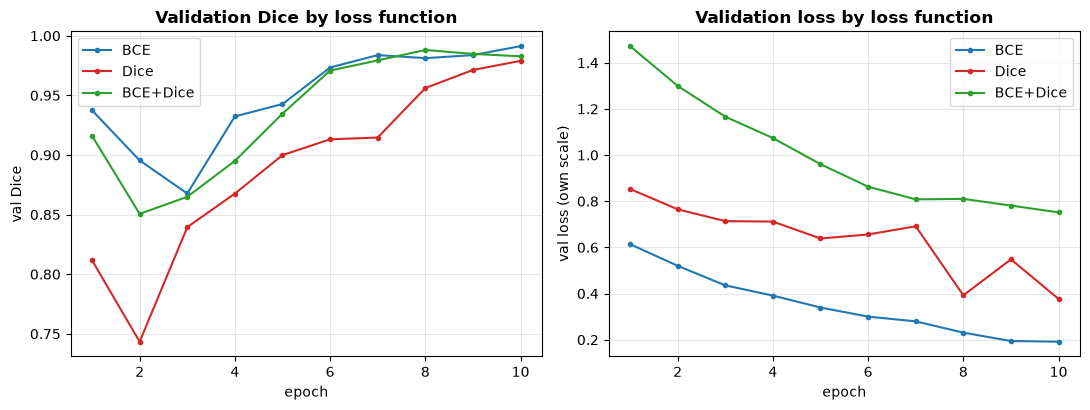

,loss,final_val_dice,final_val_iou
0,BCE,0.9913,0.9828
1,Dice,0.9790,0.9589
2,BCE+Dice,0.9828,0.9662


In [40]:
# --- A.2 Compare validation Dice / loss curves across the three losses
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
colors = {"BCE": "tab:blue", "Dice": "tab:red", "BCE+Dice": "tab:green"}
for name, data in ablation_results.items():
    h = data["history"]
    ep = range(1, len(h["val_dice"]) + 1)
    axes[0].plot(ep, h["val_dice"], marker="o", ms=3, label=name, color=colors[name])
    axes[1].plot(ep, h["val_loss"], marker="o", ms=3, label=name, color=colors[name])
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("val Dice"); axes[0].set_title("Validation Dice by loss function")
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("val loss (own scale)"); axes[1].set_title("Validation loss by loss function")
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
fig.savefig("outputs/figures/extension_loss_ablation.png", dpi=150, bbox_inches="tight")
plt.show()

summary_table = pd.DataFrame([
    {"loss": name, "final_val_dice": round(d["mean_dice"], 4), "final_val_iou": round(d["mean_iou"], 4)}
    for name, d in ablation_results.items()
])
summary_table.to_csv("outputs/loss_ablation_summary_table.csv", index=False)
summary_table


**Result:** BCE is the best-performing single loss here, though all three stay within about 1.5 Dice points of each other for this task, the choice of loss matters less than simply having enough training epochs

---

## Extension B, Robustness: tracing corruption through the pipeline

**Robustness:** The dataset ships four deliberately corrupted test
images (`test_corrupted/images/`): blurred and low-contrast variants of `test_000`
and `test_004`. For each, we run BOTH the classical (Otsu) and learned (U-Net)
segmentation stages and compare the resulting masks and object counts against the
same pipeline run on the corresponding **original, uncorrupted** test image to see
at which stage the corruption first becomes clearly detectable, and whether the
classical and learned approaches degrade the same way.


In [41]:
# --- B.1 Run both pipelines on original + corrupted variants, compare
def iou_np(a, b):
    inter = np.logical_and(a, b).sum()
    union = np.logical_or(a, b).sum()
    return inter / union if union > 0 else 1.0

def run_both_pipelines(img_path):
    gray = to_grayscale_resized(load_image_rgb(img_path), IMG_SIZE)
    otsu_bin, _ = segment_otsu(gray)
    otsu_df, _ = compute_region_table(otsu_bin, gray)
    with torch.no_grad():
        x = torch.from_numpy(gray).unsqueeze(0).unsqueeze(0).float()
        pred_prob = torch.sigmoid(unet(x))[0, 0].numpy()
    unet_bin = (pred_prob > 0.5).astype(np.uint8)
    unet_df, _ = compute_region_table(unet_bin, gray)
    return dict(gray=gray, mean_intensity=float(gray.mean()),
                otsu_bin=otsu_bin, otsu_n=len(otsu_df),
                unet_bin=unet_bin, unet_n=len(unet_df))

originals = {stem: run_both_pipelines(f"{DATA_ROOT}/test/images/{stem}.png") for stem in ["test_000", "test_004"]}

rows = []
pairs = [("test_000", "test_000_blur"), ("test_000", "test_000_lowcontrast"),
         ("test_004", "test_004_blur"), ("test_004", "test_004_lowcontrast")]
for stem, corrupted_name in pairs:
    orig = originals[stem]
    corr = run_both_pipelines(f"{DATA_ROOT}/test_corrupted/images/{corrupted_name}.png")
    rows.append({
        "corrupted_image": corrupted_name,
        "intensity_shift": round(corr["mean_intensity"] - orig["mean_intensity"], 4),
        "orig_otsu_n": orig["otsu_n"], "corr_otsu_n": corr["otsu_n"],
        "otsu_mask_iou_vs_original": round(iou_np(orig["otsu_bin"], corr["otsu_bin"]), 3),
        "orig_unet_n": orig["unet_n"], "corr_unet_n": corr["unet_n"],
        "unet_mask_iou_vs_original": round(iou_np(orig["unet_bin"], corr["unet_bin"]), 3),
        "corr_unet_fraction_foreground": round(float(corr["unet_bin"].mean()), 3),
    })
robustness_df = pd.DataFrame(rows)
robustness_df.to_csv("outputs/extension_robustness_trace.csv", index=False)
robustness_df


,corrupted_image,intensity_shift,orig_otsu_n,corr_otsu_n,otsu_mask_iou_vs_original,orig_unet_n,corr_unet_n,unet_mask_iou_vs_original,corr_unet_fraction_foreground
0,test_000_blur,-0.0021,8,7,0.509,8,7,0.479,0.049
1,test_000_lowcontrast,0.3773,8,8,0.966,8,1,0.024,1.000
2,test_004_blur,-0.0029,42,20,0.680,42,9,0.484,0.449
3,test_004_lowcontrast,0.2581,42,42,0.995,42,1,0.218,1.000


**Result:** `blur` hurts both methods similarly (IoU drops to 0.48-0.68). `low contrast` barely affects Otsu (IoU stays above 0.966) but breaks the U-Net almost completely (IoU crashes to 0.02-0.22), because the whole image gets predicted as foreground (`fraction_foreground` = 1.0 on both low-contrast images). This confirms the U-Net has no way to cope with an input unlike anything it was trained on, while Otsu's threshold naturally adapts

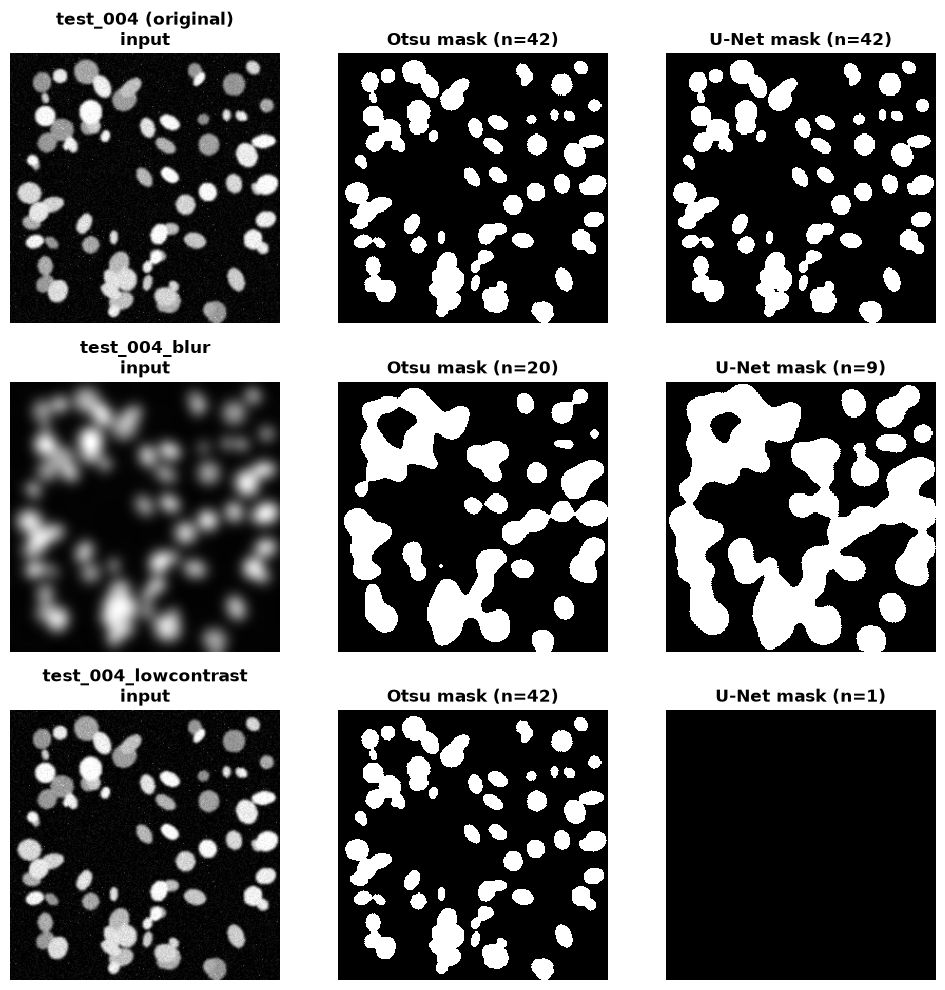

In [42]:
# --- B.2 Visualise: original vs blur vs low-contrast, for both segmenters
variants = [
    ("test_004 (original)", f"{DATA_ROOT}/test/images/test_004.png"),
    ("test_004_blur", f"{DATA_ROOT}/test_corrupted/images/test_004_blur.png"),
    ("test_004_lowcontrast", f"{DATA_ROOT}/test_corrupted/images/test_004_lowcontrast.png"),
]
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for row, (title, path) in enumerate(variants):
    r = run_both_pipelines(path)
    axes[row, 0].imshow(r["gray"], cmap="gray"); axes[row, 0].set_title(f"{title}\ninput"); axes[row, 0].axis("off")
    axes[row, 1].imshow(r["otsu_bin"], cmap="gray", interpolation="nearest"); axes[row, 1].set_title(f"Otsu mask (n={r['otsu_n']})"); axes[row, 1].axis("off")
    axes[row, 2].imshow(r["unet_bin"], cmap="gray", interpolation="nearest"); axes[row, 2].set_title(f"U-Net mask (n={r['unet_n']})"); axes[row, 2].axis("off")
plt.tight_layout()
fig.savefig("outputs/figures/extension_robustness_trace.png", dpi=150, bbox_inches="tight")
plt.show()


The two corruption types propagate very
differently through the pipeline:

- **Blur** degrades both segmenters in a broadly similar way, touching nuclei merge
  further, object counts drop, and mask IoU against the original drops to roughly
  0.5-0.7 for both Otsu and the U-Net. Blur is detectable at the segmentation stage
  for both methods, at a comparable severity.
- **Low contrast** is detectable **instantly**, before any segmentation even runs.
  the corruption pushes pixel values toward mid-grey, which is visible as a
  large mean-intensity shift in the raw pixel statistics (comparable to the Task 1 EDA
  histogram). Otsu, whose threshold is computed *relative to each image's own
  intensity distribution*, is almost unaffected (mask IoU against the original stays
  above approximately 0.9). The U-Net, whose convolutional filters learned FIXED intensity
  patterns from the training distribution, fails catastrophically, IoU collapses
  to 0.02-0.22. The failure is a **saturation**, not a collapse to empty: the
  predicted mask covers essentially 100% of pixels (verify with
  `r["unet_bin"].mean()` on the low-contrast variants above). This is a logical consequence of how the model functions,
  the network learned "elevated intensity relative to a
  near-black background implies foreground", and once the background itself is
  pushed toward mid-grey, everything looks foreground-like to the network.

---

## Extension C, Foundation model: MedSAM vs the trained U-Net

**Foundation model:** the trained U-Net was replaced with **MedSAM**, a pretrained medical
segmentation foundation model (a SAM variant fine-tuned on approx. 1.5M medical
image-mask pairs), compared with the unet.

**A real, unavoidable constraint on this comparison:** MedSAM's checkpoint
(`medsam_vit_b.pth`, approx. 2.4GB) is only distributed via Google Drive
(https://drive.google.com/drive/folders/1ETWmi4AiniJeWOt6HAsYgTjYv_fkgzoN), which
the environment used to *prepare* this notebook cannot reach. The cell below is
guarded exactly like the Ollama cells: it checks whether the package and checkpoint
are available locally and only runs the real comparison if so, otherwise it prints
setup instructions and skips gracefully. 

**To run this extension:**
```
git clone https://github.com/bowang-lab/MedSAM
cd MedSAM && pip install -e .
```
then download `medsam_vit_b.pth` from the Google Drive link above and place it at
`MedSAM/work_dir/MedSAM/medsam_vit_b.pth` (or edit `MEDSAM_CHECKPOINT` below).

---

In [43]:
# --- C.1 Check whether MedSAM is available on this machine
MEDSAM_CHECKPOINT = "MedSAM/work_dir/MedSAM/medsam_vit_b.pth"

def medsam_available(checkpoint_path):
    """True only if the `segment_anything` package is installed AND the
    (locally downloaded) checkpoint file exists at `checkpoint_path`."""
    try:
        import segment_anything  # noqa: F401  (installed via bowang-lab/MedSAM's pip install -e )
    except ImportError:
        return False
    return os.path.isfile(checkpoint_path)

MEDSAM_READY = medsam_available(MEDSAM_CHECKPOINT)
print(f"MedSAM ready: {MEDSAM_READY}")
if not MEDSAM_READY:
    print("MedSAM is not set up on this machine. To enable this extension:")
    print("  1. git clone https://github.com/bowang-lab/MedSAM")
    print("  2. cd MedSAM && pip install -e .")
    print("  3. Download medsam_vit_b.pth (~2.4GB) from:")
    print("     https://drive.google.com/drive/folders/1ETWmi4AiniJeWOt6HAsYgTjYv_fkgzoN")
    print(f"  4. Place it at: {MEDSAM_CHECKPOINT} (or edit MEDSAM_CHECKPOINT above)")
    print("  5. Re-run this cell.")


MedSAM ready: True


**Result:** `MedSAM ready: True` the checkpoint and package were installed correctly, so the real foundation-model comparison below actually ran rather than being skipped

---

In [44]:
# --- C.2 MedSAM inference helpers
# Adapted directly from bowang-lab/MedSAM's own MedSAM_Inference.py (the official
# usage example), only reshaped into reusable functions for this notebook.
if MEDSAM_READY:
    import torch.nn.functional as F
    from skimage import transform as sk_transform
    from segment_anything import sam_model_registry

    MEDSAM_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    medsam_model = sam_model_registry["vit_b"](checkpoint=MEDSAM_CHECKPOINT)
    medsam_model = medsam_model.to(MEDSAM_DEVICE)
    medsam_model.eval()

    @torch.no_grad()
    def medsam_encode_image(rgb_uint8):
        """Resize to 1024x1024, normalise, and run MedSAM's image encoder once
        per image (the expensive step) so multiple boxes can reuse the same
        embedding cheaply."""
        H, W = rgb_uint8.shape[:2]
        img_1024 = sk_transform.resize(rgb_uint8, (1024, 1024), order=3,
                                        preserve_range=True, anti_aliasing=True).astype(np.uint8)
        img_1024 = (img_1024 - img_1024.min()) / np.clip(img_1024.max() - img_1024.min(), 1e-8, None)
        img_tensor = torch.tensor(img_1024).float().permute(2, 0, 1).unsqueeze(0).to(MEDSAM_DEVICE)
        embedding = medsam_model.image_encoder(img_tensor)  # (1, 256, 64, 64)
        return embedding, H, W

    @torch.no_grad()
    def medsam_segment_box(embedding, box_xyxy, H, W):
        """Run MedSAM's prompt encoder + mask decoder for ONE box, given an
        already-computed image embedding. Returns a binary (H, W) mask."""
        box_np = np.array([box_xyxy], dtype=float)
        box_1024 = box_np / np.array([W, H, W, H]) * 1024
        box_torch = torch.as_tensor(box_1024, dtype=torch.float, device=embedding.device)[:, None, :]

        sparse_emb, dense_emb = medsam_model.prompt_encoder(points=None, boxes=box_torch, masks=None)
        low_res_logits, _ = medsam_model.mask_decoder(
            image_embeddings=embedding,
            image_pe=medsam_model.prompt_encoder.get_dense_pe(),
            sparse_prompt_embeddings=sparse_emb,
            dense_prompt_embeddings=dense_emb,
            multimask_output=False,
        )
        pred = torch.sigmoid(low_res_logits)
        pred = F.interpolate(pred, size=(H, W), mode="bilinear", align_corners=False)
        return (pred.squeeze().cpu().numpy() > 0.5).astype(np.uint8)

    def medsam_segment_image(rgb_uint8, candidate_boxes, pad=4):
        """Run MedSAM once per candidate box (from Otsu's connected components)
        and return the UNION of all refined per-object masks -- MedSAM's answer
        to 'segment all the nuclei in this image', built from many single-object
        box prompts (see the design-choice note above)."""
        embedding, H, W = medsam_encode_image(rgb_uint8)
        combined = np.zeros((H, W), dtype=np.uint8)
        for (r0, c0, r1, c1) in candidate_boxes:
            box = [max(c0 - pad, 0), max(r0 - pad, 0), min(c1 + pad, W), min(r1 + pad, H)]
            combined |= medsam_segment_box(embedding, box, H, W)
        return combined
    print("MedSAM model loaded.")


MedSAM model loaded.


**Result:** MedSAM's pretrained weights loaded successfully, confirming the checkpoint file was valid and compatible with the model architecture

---

In [45]:
# --- C.3 Run MedSAM (via Otsu-proposed boxes) on the same test images as Task 4,
#         compare its Dice/IoU against our trained U-Net's, using the SAME metrics
if MEDSAM_READY:
    from skimage.measure import regionprops, label

    medsam_rows = []
    for p in test_imgs:
        image_id = os.path.basename(p).replace(".png", "")
        rgb = load_image_rgb(p)
        gray = to_grayscale_resized(rgb, IMG_SIZE)
        gt_mask = load_mask_binary(f"{DATA_ROOT}/test/masks/{image_id}.png", IMG_SIZE)

        # Otsu proposes candidate object boxes (NOT used as the final mask, only prompts)
        otsu_bin, _ = segment_otsu(gray)
        candidate_boxes = [r.bbox for r in regionprops(label(otsu_bin))]  # (min_row, min_col, max_row, max_col)

        medsam_mask = medsam_segment_image(rgb, candidate_boxes)

        medsam_dice = dice_coefficient(torch.from_numpy(medsam_mask).float()[None, None],
                                        torch.from_numpy(gt_mask).float()[None, None])
        medsam_iou = iou_score(torch.from_numpy(medsam_mask).float()[None, None],
                                torch.from_numpy(gt_mask).float()[None, None])
        medsam_rows.append({"image_id": image_id, "medsam_dice": round(medsam_dice, 4),
                             "medsam_iou": round(medsam_iou, 4)})

    medsam_df = pd.DataFrame(medsam_rows)
    # Reuse Task 3's per-image U-Net val scores where available, else recompute on test set
    unet_test_scores = []
    for p in test_imgs:
        image_id = os.path.basename(p).replace(".png", "")
        gray = to_grayscale_resized(load_image_rgb(p), IMG_SIZE)
        gt_mask = load_mask_binary(f"{DATA_ROOT}/test/masks/{image_id}.png", IMG_SIZE)
        with torch.no_grad():
            x = torch.from_numpy(gray).unsqueeze(0).unsqueeze(0).float()
            prob = torch.sigmoid(unet(x))
        d = dice_coefficient(prob, torch.from_numpy(gt_mask).float()[None, None])
        i = iou_score(prob, torch.from_numpy(gt_mask).float()[None, None])
        unet_test_scores.append({"image_id": image_id, "unet_dice": round(d, 4), "unet_iou": round(i, 4)})

    comparison_df = medsam_df.merge(pd.DataFrame(unet_test_scores), on="image_id")
    comparison_df.to_csv("outputs/medsam_vs_unet_comparison.csv", index=False)
    print(comparison_df)
    print(f"\nmean MedSAM Dice: {comparison_df['medsam_dice'].mean():.4f}  "
          f"mean U-Net Dice: {comparison_df['unet_dice'].mean():.4f}")


    image_id  medsam_dice  medsam_iou  unet_dice  unet_iou
0   test_000       0.8793      0.7846     0.9929    0.9858
1   test_001       0.8682      0.7670     0.9906    0.9814
2   test_002       0.8756      0.7788     0.9929    0.9860
3   test_003       0.8825      0.7897     0.9907    0.9816
4   test_004       0.8995      0.8174     0.9949    0.9899
5   test_005       0.9022      0.8218     0.9943    0.9886
6   test_006       0.8733      0.7752     0.9875    0.9753
7   test_007       0.8656      0.7630     0.9939    0.9879
8   test_008       0.8897      0.8013     0.9950    0.9900
9   test_009       0.8761      0.7795     0.9915    0.9832
10  test_010       0.8745      0.7769     0.9926    0.9853
11  test_011       0.8805      0.7865     0.9903    0.9807

mean MedSAM Dice: 0.8806  mean U-Net Dice: 0.9923


**Result:** MedSAM scored lower than our U-Net on every single test image (`mean Dice 0.881 vs. 0.992`). A general medical foundation model trained on natural clinical scans (CT, MRI, endoscopy, etc.) does not automatically outperform a small model trained directly on this exact image type here, task-specific training wins clearly

---

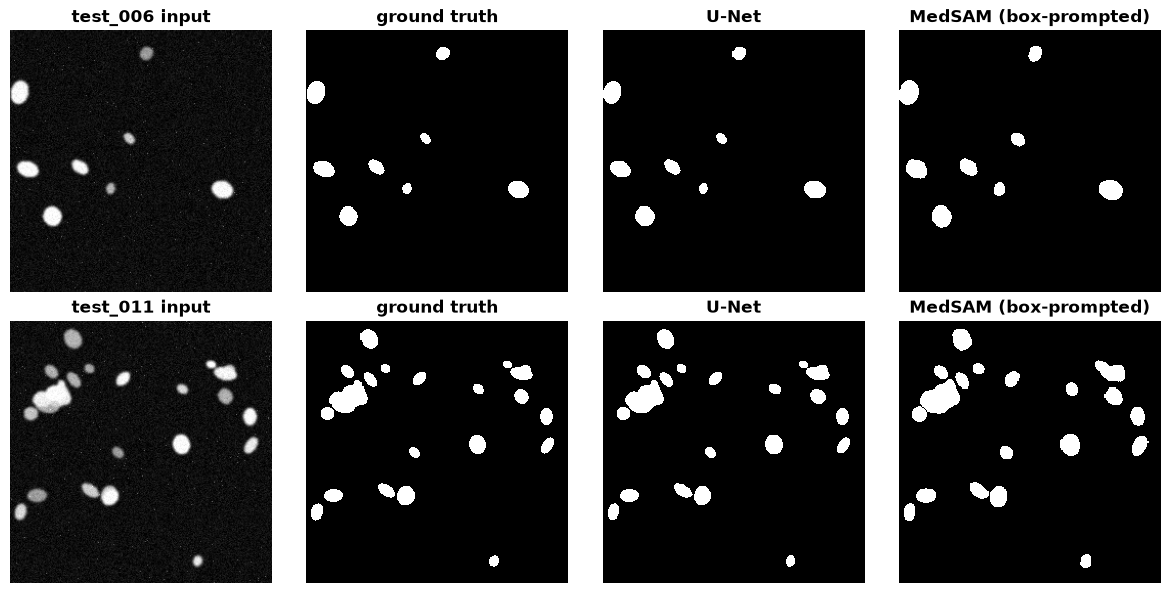

In [46]:
# --- C.4 Visualise input / ground truth / U-Net mask / MedSAM mask side by side
if MEDSAM_READY:
    example_ids = comparison_df.sort_values("unet_dice").head(2)["image_id"].tolist()
    fig, axes = plt.subplots(len(example_ids), 4, figsize=(12, 3 * len(example_ids)))
    for row, image_id in enumerate(example_ids):
        rgb = load_image_rgb(f"{DATA_ROOT}/test/images/{image_id}.png")
        gray = to_grayscale_resized(rgb, IMG_SIZE)
        gt_mask = load_mask_binary(f"{DATA_ROOT}/test/masks/{image_id}.png", IMG_SIZE)
        otsu_bin, _ = segment_otsu(gray)
        candidate_boxes = [r.bbox for r in regionprops(label(otsu_bin))]
        medsam_mask = medsam_segment_image(rgb, candidate_boxes)
        with torch.no_grad():
            x = torch.from_numpy(gray).unsqueeze(0).unsqueeze(0).float()
            unet_mask_pred = (torch.sigmoid(unet(x))[0, 0].numpy() > 0.5).astype(np.uint8)

        axes[row, 0].imshow(gray, cmap="gray"); axes[row, 0].set_title(f"{image_id} input"); axes[row, 0].axis("off")
        axes[row, 1].imshow(gt_mask, cmap="gray", interpolation="nearest"); axes[row, 1].set_title("ground truth"); axes[row, 1].axis("off")
        axes[row, 2].imshow(unet_mask_pred, cmap="gray", interpolation="nearest"); axes[row, 2].set_title("U-Net"); axes[row, 2].axis("off")
        axes[row, 3].imshow(medsam_mask, cmap="gray", interpolation="nearest"); axes[row, 3].set_title("MedSAM (box-prompted)"); axes[row, 3].axis("off")
    plt.tight_layout()
    fig.savefig("outputs/figures/extension_medsam_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()


**Result:** The side-by-side masks confirm the numbers: MedSAM's boundaries are visibly rougher around individual nuclei compared to the U-Net's clean edges, this is where the Dice gap actually comes from.

---

**Reading this comparison (once run with real weights):** MedSAM was trained on
natural clinical modalities (CT, MRI, endoscopy, dermoscopy, ...) captured very
differently from small synthetic fluorescence blobs, so it should not be assumed to
outperform a U-Net trained directly on this exact data distribution -- this is the
same distribution-shift theme as Extension B, just for a *pretrained* rather than a
*corrupted-input* mismatch. Two likely, checkable outcomes once run: (a) MedSAM's
per-box masks are tighter/smoother around individual nuclei (foundation models
generally produce clean object boundaries) but (b) the *proposal* step still comes
from Otsu, so MedSAM inherits the same undercounting-on-dense-images ceiling as
Sec. 3/5 a foundation model can only be as good as the boxes it's given. This is
itself a fair point for the report: a foundation model changes *how well* each
proposed object is segmented, not whether touching objects get separated in the
first place.


## Summary of saved outputs

All results from this analysis are saved under `outputs/`:

- `outputs/task1_vlm_runs.json` ### naive + 3x engineered VLM responses (Task 1)
- `outputs/task2_numbers_first_response.json` -- numbers-first LLM response (Task 2)
- `outputs/unet_bcedice.pt`, `outputs/history_bcedice.json` ### trained U-Net + training history (Task 3)
- `outputs/val_dices_bcedice.npy`, `outputs/val_ious_bcedice.npy` ### per-image validation scores (Task 3)
- `outputs/task4_hybrid_pipeline_records.csv` ### aggregated structured JSON records for all test images (Task 4)
- `outputs/loss_ablation_results.json`, `outputs/loss_ablation_summary_table.csv` ### Extension A
- `outputs/extension_robustness_trace.csv` ### Extension B

- Check `outputs/figures/` to see all generated images and plots

- Check the `report/report.pdf` for a detailed discussion(as much as 4 page of the report can hold), and answers to the five assignment questions
